Battle of Styles: March Madness Matchup Predictor

Author: Ethan Kessler 

Description: Predict which team wins a March Madness matchup based on playstyle stats

In [383]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

## Load and Combine Data 

(2011–2025, not 2020 since it was cancelled due to COVID-19) 

In [384]:


#Load and Combine Data (2011–2025, not 2020 since it was cancelled due to COVID-19) ---

file_base = 'https://raw.githubusercontent.com/christoukmaji/MarchMadnessDatasets/refs/heads/main/'
all_years_data = []
for year in range(2011, 2026):
    if year == 2020:
        continue
    df = pd.read_csv(f'{file_base}{year}.csv')
    df['Year'] = year
    all_years_data.append(df)

#Combine into one DataFrame
full_df = pd.concat(all_years_data, ignore_index=True)



In [385]:

#Add New Features: TeamName, Seed, Rank, Conference

full_df['TeamName'] = full_df['Name+Seed'].str.extract(r"([A-Za-z &'-]+)")
full_df['Seed'] = full_df['Name+Seed'].str.extract(r"(\d+)$").astype(float)

# Ensure Rank and Conference exist (if missing)
if 'Rank' not in full_df.columns:
    full_df['Rank'] = np.nan
if 'Conference' not in full_df.columns:
    full_df['Conference'] = 'Unknown'


In [386]:

#Feature Engineering Stat Differences
df_model = pd.DataFrame()
df_model['OffEff_Diff'] = full_df['AdjO'] - full_df['OppO']
df_model['DefEff_Diff'] = full_df['AdjD'] - full_df['OppD']
df_model['Tempo_Diff'] = full_df['AdjT'] - full_df['AdjT'].mean()
df_model['Luck_Diff'] = full_df['Luck'] - full_df['Luck'].mean()

# Add Extra Features (TeamName, Seed, Rank, Conference)
df_model['TeamName'] = full_df['TeamName']
df_model['Seed'] = full_df['Seed']
df_model['Rank'] = full_df['Rank']
df_model['Conference'] = full_df['Conference']
df_model['Winner'] = (
full_df['W_64'] + full_df['W_32'] + full_df['W_16'] +
full_df['W_8'] + full_df['W_4'] + full_df['W_2']
)

df_model['Pairs_of_rounds_won'] = df_model['Winner'] / 2.0

# round the values to the nearest integer
df_model['Pairs_of_rounds_won'] = df_model['Pairs_of_rounds_won'].round().astype(int)



In [387]:

# #Combine original and mirror datasets

# df_final = pd.concat([df_model, df_mirror], ignore_index=True)
df_final = df_model.copy()

#Standardize Features for PCA and Random Forest

# Drop non-numeric columns for training
X = df_final.drop(columns=['Winner', 'Pairs_of_rounds_won', 'TeamName', 'Conference'])
y = df_final['Pairs_of_rounds_won']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [388]:


# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

#Train Random Forest on PCA Components
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)



Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.89      0.87       142
           1       0.13      0.11      0.12        19
           2       0.29      0.21      0.24        19

    accuracy                           0.74       180
   macro avg       0.42      0.40      0.41       180
weighted avg       0.71      0.74      0.72       180

Confusion Matrix:

[[127   8   7]
 [ 14   2   3]
 [ 10   5   4]]


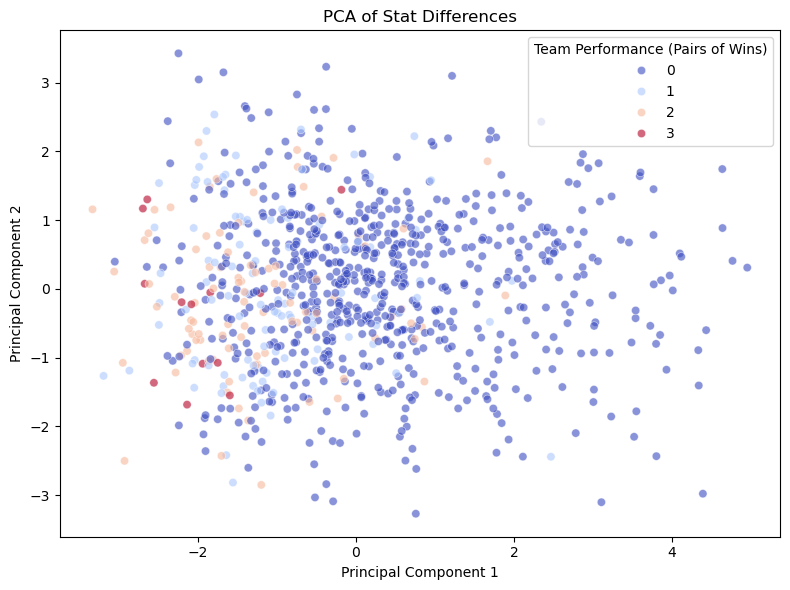

In [389]:

#Model Evaluation (PCA Random Forest)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

#PCA Visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='coolwarm', alpha=0.6)
plt.title("PCA of Stat Differences")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Team Performance (Pairs of Wins)")
plt.tight_layout()
plt.show()



In [390]:

#Feature Importance (Random Forest on Original Stat Differences)
X_orig_train, X_orig_test, y_orig_train, y_orig_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_orig_train, y_orig_train)
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
'Feature': X.columns,
'Importance': importances
}).sort_values(by='Importance', ascending=False)


/var/folders/4t/_28pxz5s6pd6k2mk3r529dt40000gn/T/ipykernel_79876/3118228467.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


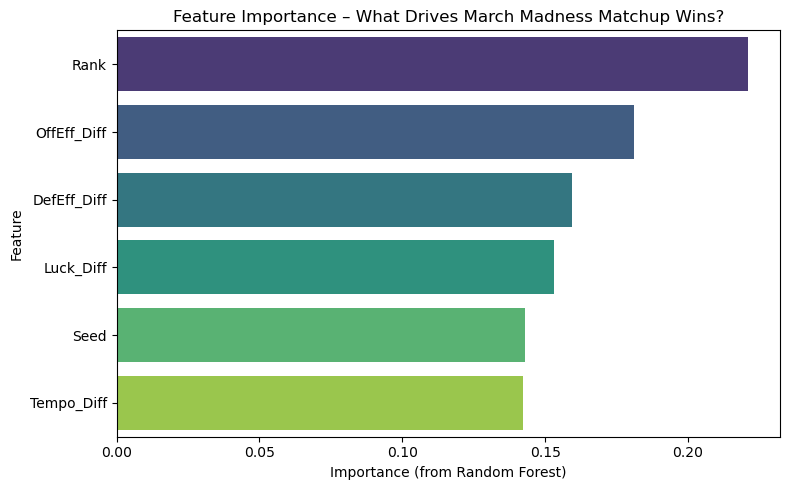

In [391]:

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title("Feature Importance – What Drives March Madness Matchup Wins?")
plt.xlabel("Importance (from Random Forest)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# Filter Games Involving Final Four Teams

In [392]:
full_df['TeamName'] = full_df['Name+Seed'].str.extract(r"([A-Za-z &'-]+)")
df_ff_games = full_df[full_df['W_8'] == 1]

print("\nFinal Four Games DataFrame:\n")
print(df_ff_games)

#Feature Engineering on Final Four Games
df_model = pd.DataFrame()
# df_model['OffEff_Diff'] = df_ff_games['AdjO'] - df_ff_games['OppO']
# df_model['DefEff_Diff'] = df_ff_games['AdjD'] - df_ff_games['OppD']
# df_model['Tempo_Diff'] = df_ff_games['AdjT'] - df_ff_games['AdjT'].mean()
# df_model['Luck_Diff'] = df_ff_games['Luck'] - df_ff_games['Luck'].mean()
df_model['AdjO'] = df_ff_games['AdjO']
df_model['AdjD'] = df_ff_games['AdjD']
df_model['AdjT'] = df_ff_games['AdjT']
df_model['Luck'] = df_ff_games['Luck']
df_model['Year'] = df_ff_games['Year']


Final Four Games DataFrame:

                    Name+Seed              Pure Text  Rank Conference    W-L  \
6                  Kentucky 4               Kentucky     9        SEC   26-8   
26              Connecticut 3            Connecticut    14         BE   27-9   
41   Virginia Commonwealth 11  Virginia Commonwealth    77        CAA  24-11   
50                   Butler 8                 Butler    48       Horz   24-9   
64                 Kentucky 1               Kentucky     2        SEC   32-2   
86               Louisville 4             Louisville    20         BE   26-9   
110                Ohio St. 2               Ohio St.     1        B10   27-7   
126                  Kansas 2                 Kansas     4        B12   27-6   
128              Louisville 1             Louisville     2         BE   29-5   
147             Wichita St. 9            Wichita St.    33        MVC   26-8   
166                Michigan 4               Michigan    11        B10   26-7   
182       

this was just for me for debugging 

In [393]:

# Add Extra Features
df_model['TeamName'] = df_ff_games['TeamName']
df_model['Seed'] = df_ff_games['Seed']
df_model['Rank'] = df_ff_games['Rank']
df_model['Conference'] = df_ff_games['Conference']
df_model['Winner'] = (
    df_ff_games['W_64'] + df_ff_games['W_32'] + df_ff_games['W_16'] +
    df_ff_games['W_8'] + df_ff_games['W_4'] + df_ff_games['W_2']
)

df_final = df_model.copy()

In [394]:
##Standardize Final Four Features
# X = df_final.drop(columns=['Winner', 'TeamName', 'Conference', 'Year', 'AdjO', 'AdjD', 'AdjT', 'Luck'])
X = df_final.drop(columns=['Winner', 'TeamName', 'Conference', 'Year'])

y = df_final['Winner']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [395]:
X

,AdjO,AdjD,AdjT,Luck,Seed,Rank
6,118.8,91.4,66.3,-0.051,4.0,9
26,116.3,91.8,66.1,0.029,3.0,14
41,109.5,99.7,66.3,0.021,11.0,77
50,111.7,96.6,64.4,0.006,8.0,48
64,120.8,87.2,65.7,0.025,1.0,2
86,103.7,84.7,67.7,0.021,4.0,20
110,117.1,84.3,67.9,-0.053,2.0,1
126,117.0,87.7,67.7,0.010,2.0,4
128,114.6,81.0,67.2,-0.030,1.0,2
147,109.1,91.3,64.6,-0.002,9.0,33


In [396]:
# PCA on Final Four Games
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


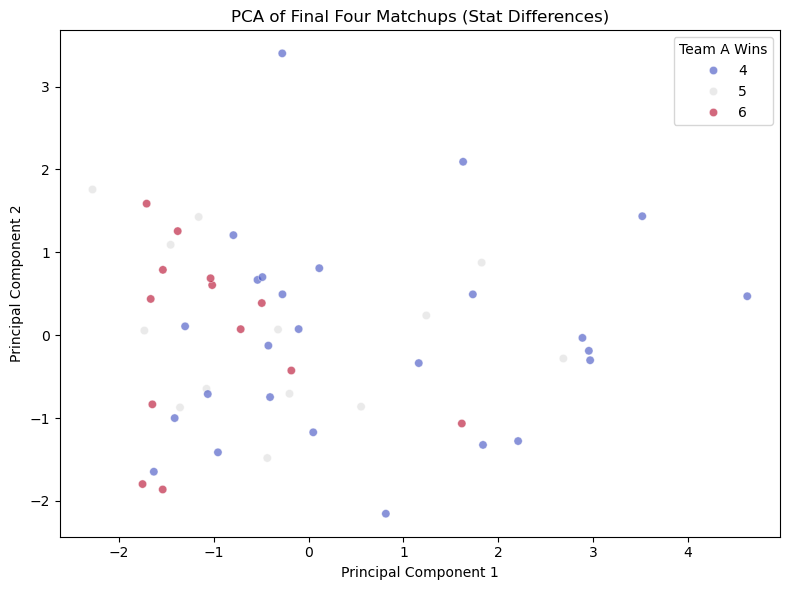

In [397]:

#PCA Visualization for Final Four Matchups
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, alpha=0.6, palette = 'coolwarm')
plt.title("PCA of Final Four Matchups (Stat Differences)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Team A Wins")#, labels = ['Elite 8', 'Final Four', 'Finals'])
plt.tight_layout()
plt.show()


In [398]:

#Train and Evaluate Random Forest (Final Four Games)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.5, random_state=42)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_pred_train = rf.predict(X_train)

print("\nTrain Classification Report:\n")
print(classification_report(y_train, y_pred_train))
print("Train Confusion Matrix:\n")
print(confusion_matrix(y_train, y_pred_train))

print("\nClassification Report (Final Four Matchups):\n")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Train Classification Report:

              precision    recall  f1-score   support

           4       1.00      1.00      1.00        15
           5       1.00      1.00      1.00         6
           6       1.00      1.00      1.00         5

    accuracy                           1.00        26
   macro avg       1.00      1.00      1.00        26
weighted avg       1.00      1.00      1.00        26

Train Confusion Matrix:

[[15  0  0]
 [ 0  6  0]
 [ 0  0  5]]

Classification Report (Final Four Matchups):

              precision    recall  f1-score   support

           4       0.44      0.64      0.52        11
           5       0.14      0.14      0.14         7
           6       0.33      0.12      0.18         8

    accuracy                           0.35        26
   macro avg       0.30      0.30      0.28        26
weighted avg       0.33      0.35      0.31        26

Confusion Matrix:

[[7 3 1]
 [5 1 1]
 [4 3 1]]


it seems that farther a team goes into the tournament it is almost left up to chance and might not be able to perfectly predict 

/var/folders/4t/_28pxz5s6pd6k2mk3r529dt40000gn/T/ipykernel_79876/1311913702.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


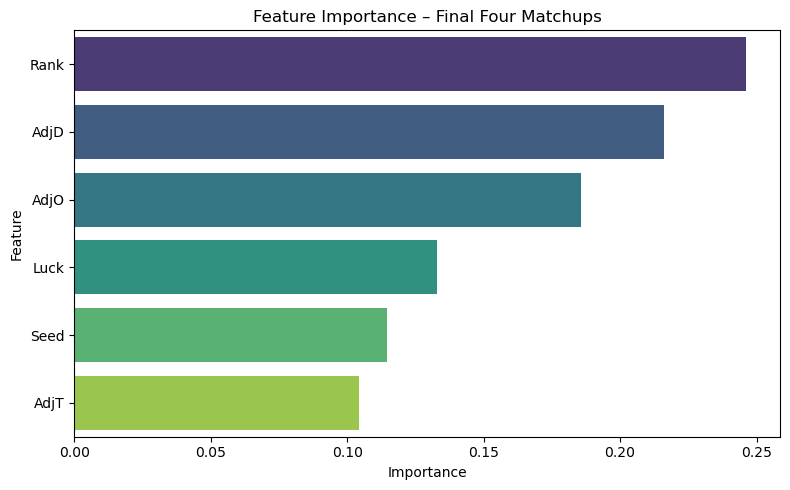

In [399]:

#Feature Importance (Final Four Games)
importances = rf.feature_importances_
importance_df = pd.DataFrame({
'Feature': X.columns,
'Importance': importances
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(8,5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title("Feature Importance – Final Four Matchups")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Clustering Final Four Teams 

In [400]:
##Extract Final Four Team Rows from full_df
full_df['TeamName'] = full_df['Name+Seed'].str.extract(r"([A-Za-z &'-]+)")
ff_team_rows = [(year, team) for year, teams in final_four_true.items() for team in teams]
ff_df = pd.DataFrame(ff_team_rows, columns=['Year', 'TeamName'])
ff_df['FinalFour'] = 1

##Merge to get stats for just Final Four teams
ff_stats = pd.merge(ff_df, full_df, on=['Year', 'TeamName'], how='left').drop_duplicates(subset=['Year', 'TeamName'])

In [401]:
##Select Stats for Clustering
cluster_features = ['AdjO', 'AdjD', 'AdjT', 'Luck', 'Seed', 'Rank']

# ff_stats = ff_stats.dropna(subset=cluster_features)
ff_stats = df_model.dropna(subset=cluster_features)
X = ff_stats[cluster_features]

##Standardize the Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [402]:
##Run K-Means Clustering
k = 3 # Change this to test other numbers of clusters
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

##Add Cluster Labels to DataFrame
ff_stats['Cluster'] = clusters


##PCA for 2D Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
ff_stats['PC1'] = X_pca[:, 0]
ff_stats['PC2'] = X_pca[:, 1]

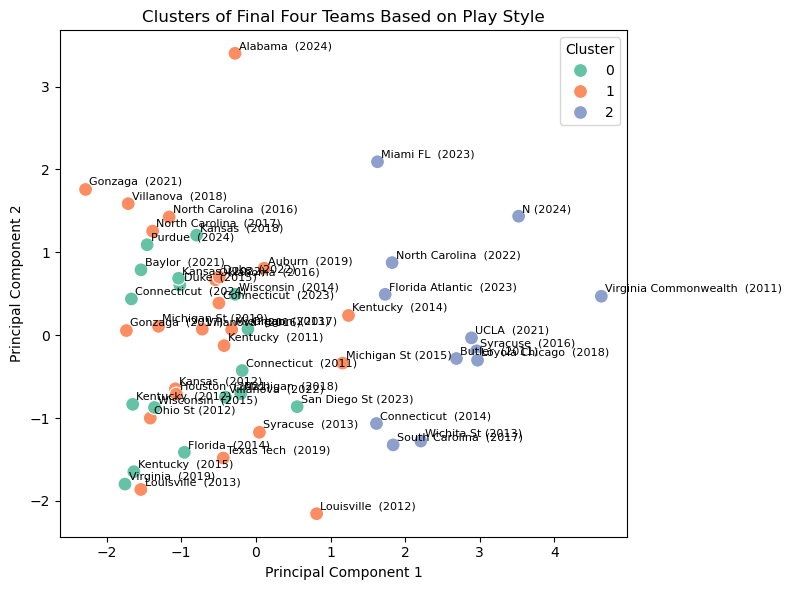

     Year                TeamName  Cluster   AdjO   AdjD  AdjT   Luck  Seed  \
6    2011               Kentucky         1  118.8   91.4  66.3 -0.051   4.0   
26   2011            Connecticut         0  116.3   91.8  66.1  0.029   3.0   
41   2011  Virginia Commonwealth         2  109.5   99.7  66.3  0.021  11.0   
50   2011                 Butler         2  111.7   96.6  64.4  0.006   8.0   
64   2012               Kentucky         0  120.8   87.2  65.7  0.025   1.0   
86   2012             Louisville         1  103.7   84.7  67.7  0.021   4.0   
110  2012                 Ohio St        1  117.1   84.3  67.9 -0.053   2.0   
126  2012                 Kansas         1  117.0   87.7  67.7  0.010   2.0   
128  2013             Louisville         1  114.6   81.0  67.2 -0.030   1.0   
147  2013              Wichita St        2  109.1   91.3  64.6 -0.002   9.0   
166  2013               Michigan         1  120.6   93.9  65.0 -0.011   4.0   
182  2013               Syracuse         1  114.2   

In [403]:

##Plot Clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(data=ff_stats, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=100)
for i, row in ff_stats.iterrows():
    plt.text(row['PC1'] + 0.05, row['PC2'] + 0.05, f"{row['TeamName']} ({row['Year']})", fontsize=8)


plt.title("Clusters of Final Four Teams Based on Play Style")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

##Optional: View Cluster Assignments
print(ff_stats[['Year', 'TeamName', 'Cluster'] + cluster_features])
